### 2.1.1 非线性激活函数的重要性

假设隐藏层无激活函数：$\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$，输出层：$\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$。代入得：
$$
\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2).
$$
令 $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$，$\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$，则 $\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'$，是一个单层线性网络。因此，若无非线性激活函数，多层感知机退化为线性模型，无法拟合非线性函数。

### 2.1.2 激活函数导数关系

- Sigmoid 函数：  
  $$
  \sigma(x) = \frac{1}{1+e^{-x}}, \quad \sigma'(x) = \sigma(x)(1-\sigma(x)).
  $$
- tanh 函数：  
  $$
  \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}, \quad \tanh'(x) = 1 - \tanh^2(x).
  $$

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cpu')
print(f"Using device: {device}")

# 加载数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
batch_size = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 定义模型
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, output_size=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(-1, 784)
        h = self.relu(self.fc1(x))
        out = self.fc2(h)
        return out

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # 测试
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Test Acc: {acc:.4f}")

Using device: cpu
Epoch 1, Loss: 0.6689, Test Acc: 0.7990
Epoch 2, Loss: 0.4687, Test Acc: 0.7684
Epoch 3, Loss: 0.4207, Test Acc: 0.8374
Epoch 4, Loss: 0.3970, Test Acc: 0.8243
Epoch 5, Loss: 0.3731, Test Acc: 0.8480
Epoch 6, Loss: 0.3582, Test Acc: 0.8320
Epoch 7, Loss: 0.3438, Test Acc: 0.8617
Epoch 8, Loss: 0.3321, Test Acc: 0.8541
Epoch 9, Loss: 0.3221, Test Acc: 0.8267
Epoch 10, Loss: 0.3158, Test Acc: 0.8662


: 

### 3.1.1 训练误差 vs 泛化误差

- **训练误差**：模型在训练数据集上的平均损失。
- **泛化误差**：模型在未知测试数据（同分布）上的期望损失。

当训练误差极低但泛化误差很高时，模型处于 **过拟合** 状态。  
**缓解方法**（控制模型复杂度）：
- 减少模型层数或神经元数量
- 增加训练数据量或数据增强
- 加入正则化（L1/L2、Dropout）
- 早停（Early stopping）

### 3.1.2 K折交叉验证算法步骤

1. 将数据集随机划分为 K 个大小相近的互斥子集。
2. 对于 k = 1, 2, …, K：
   - 将第 k 个子集作为验证集，其余 K-1 个子集合并作为训练集。
   - 在训练集上训练模型，在验证集上评估性能（如准确率、损失）。
3. 计算 K 次评估指标的平均值，作为模型性能的最终估计。

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# 生成多项式数据（y 值范围大，需要标准化）
def generate_poly_data(n_samples=300, noise=0.1):
    X = np.random.randn(n_samples, 1) * 2
    y = 2 * X**3 - X**2 + 0.5*X + 0.1*np.sin(10*X) + noise * np.random.randn(n_samples, 1)
    return X.astype(np.float32), y.astype(np.float32)

X_train, y_train = generate_poly_data(200)
X_val, y_val = generate_poly_data(100)

# 标准化 y（关键！防止 loss 爆炸）
y_mean = y_train.mean()
y_std = y_train.std()
y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std

# 转换为 TensorDataset 和 DataLoader
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train_norm)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val_norm)), batch_size=32, shuffle=False)

# 定义 MLP 回归模型（使用 nn.Module）
class MLPRegressor(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
        # 初始化权重，帮助稳定训练
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)

# 训练函数（使用优化器，不手动更新梯度）
def train_model(model, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=0.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            # 梯度裁剪（防止梯度爆炸）
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                pred = model(Xb)
                loss = criterion(pred, yb)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        
        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1}: Train Loss {train_losses[-1]:.4f}, Val Loss {val_losses[-1]:.4f}")
    return train_losses, val_losses

# 三种情况对比
print("Training without regularization...")
model1 = MLPRegressor(dropout=0.0)
train1, val1 = train_model(model1, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=0.0)

print("\nTraining with L2 regularization (weight_decay=0.001)...")
model2 = MLPRegressor(dropout=0.0)
train2, val2 = train_model(model2, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=0.001)

print("\nTraining with Dropout (p=0.5)...")
model3 = MLPRegressor(dropout=0.5)
train3, val3 = train_model(model3, train_loader, val_loader, epochs=200, lr=0.001, weight_decay=0.0)


Training without regularization...
Epoch 50: Train Loss 0.0183, Val Loss 0.0045
Epoch 100: Train Loss 0.0037, Val Loss 0.0011
Epoch 150: Train Loss 0.0010, Val Loss 0.0013
Epoch 200: Train Loss 0.0006, Val Loss 0.0004

Training with L2 regularization (weight_decay=0.001)...
Epoch 50: Train Loss 0.0212, Val Loss 0.0085
Epoch 100: Train Loss 0.0071, Val Loss 0.0010
Epoch 150: Train Loss 0.0046, Val Loss 0.0019
Epoch 200: Train Loss 0.0067, Val Loss 0.0013

Training with Dropout (p=0.5)...
Epoch 50: Train Loss 0.0842, Val Loss 0.0279
Epoch 100: Train Loss 0.0486, Val Loss 0.0060
Epoch 150: Train Loss 0.0807, Val Loss 0.0067
Epoch 200: Train Loss 0.0392, Val Loss 0.0027


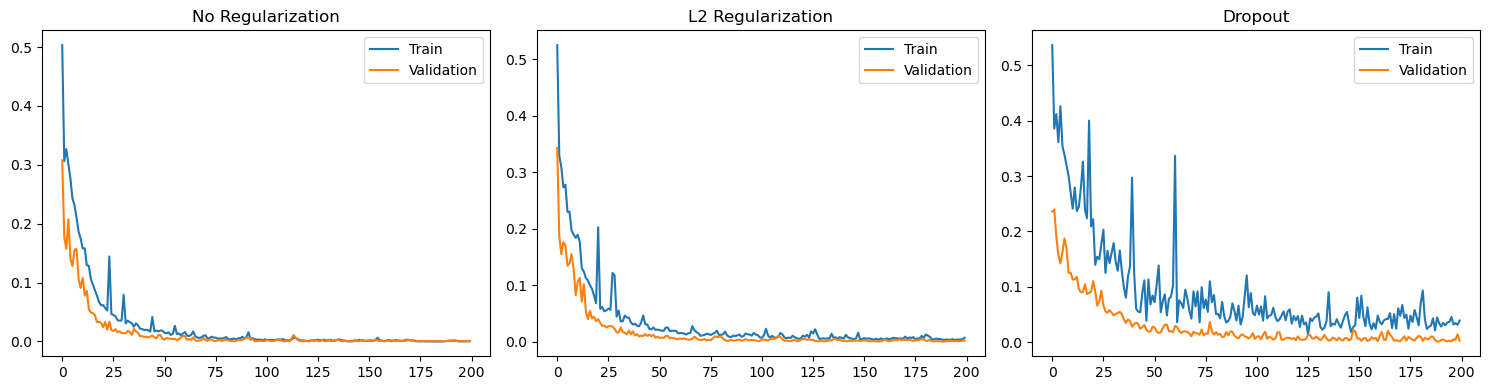

In [4]:
# 绘制损失曲线
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.plot(train1, label='Train')
plt.plot(val1, label='Validation')
plt.title('No Regularization')
plt.legend()

plt.subplot(1,3,2)
plt.plot(train2, label='Train')
plt.plot(val2, label='Validation')
plt.title('L2 Regularization')
plt.legend()

plt.subplot(1,3,3)
plt.plot(train3, label='Train')
plt.plot(val3, label='Validation')
plt.title('Dropout')
plt.legend()
plt.tight_layout()
plt.show()

### 4.1.1 梯度消失与爆炸的量化分析

深度网络中，梯度反向传播涉及多个雅可比矩阵连乘：
$$
\frac{\partial L}{\partial h^{t}} = \frac{\partial L}{\partial h^{d}} \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}},
$$
其中 $\frac{\partial h^{i+1}}{\partial h^{i}} = \sigma'(z^{i}) W^{i}$（$\sigma'$ 为激活函数导数，$W^{i}$ 为权重矩阵）。

- **梯度爆炸**：当 $W^{i}$ 的特征值 > 1 且 $\sigma'$ 不小（如 ReLU 正区为 1）时，连乘导致梯度指数增长。
- **梯度消失**：当 $W^{i}$ 的特征值 < 1 或 $\sigma'$ 很小（如 sigmoid 饱和区 $\sigma' \approx 0$）时，连乘结果趋于 0。

### 4.1.2 ReLU 缓解梯度消失的原因

ReLU 函数及其导数：
$$
\text{ReLU}(x)=\max(0,x), \quad \text{ReLU}'(x)=
\begin{cases}
1 & x>0\\
0 & x<0
\end{cases}
$$
在正区间导数恒为 1，不会像 sigmoid/tanh 那样在饱和区导数趋近 0。因此梯度连乘时只取决于权重矩阵，从而有效避免梯度消失。

In [5]:
import torch
import torch.nn as nn
import numpy as np

# 构建 20 层全连接网络
def build_deep_net(activation='sigmoid', init_method='normal', init_std=1.0):
    layers = []
    for _ in range(20):
        linear = nn.Linear(256, 256)
        if init_method == 'normal':
            nn.init.normal_(linear.weight, mean=0, std=init_std)
        elif init_method == 'xavier':
            nn.init.xavier_uniform_(linear.weight)
        layers.append(linear)
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers.append(nn.LeakyReLU(0.2))
    return nn.Sequential(*layers)

def compute_gradient_norms(model, x):
    model.zero_grad()
    out = model(x)
    loss = out.sum()
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            norms.append(param.grad.norm().item())
    return norms

x = torch.randn(64, 256)   # 输入数据

# 实验1: Sigmoid + 标准正态初始化 (std=1)
print("Experiment 1: Sigmoid + normal(0,1)")
model1 = build_deep_net('sigmoid', 'normal', 1.0)
norms1 = compute_gradient_norms(model1, x)
print(f"Gradient norms - first 5 layers: {norms1[:5]}")
print(f"               last 5 layers: {norms1[-5:]}")

# 实验2: ReLU + 大初始化 (std=10) —— 可能导致 NaN
print("\nExperiment 2: ReLU + normal(0,10)")
model2 = build_deep_net('relu', 'normal', 10.0)
try:
    norms2 = compute_gradient_norms(model2, x)
    print("No NaN, gradient norms (first 5):", norms2[:5])
except Exception as e:
    print(f"Error occurred (likely NaN): {e}")

# 实验3: Xavier初始化 + ReLU（修复）
print("\nExperiment 3: Xavier + ReLU")
model3 = build_deep_net('relu', 'xavier')
norms3 = compute_gradient_norms(model3, x)
print(f"Gradient norms - first 5 layers: {norms3[:5]}")
print(f"               last 5 layers: {norms3[-5:]}")
print("All gradients are in reasonable range (e.g., 1e-6 ~ 1e3)")

Experiment 1: Sigmoid + normal(0,1)
Gradient norms - first 5 layers: [8937.9990234375, 6622.5712890625, 5274.5830078125, 4154.53369140625, 3296.259521484375]
               last 5 layers: [464.7332763671875, 482.61932373046875, 567.544677734375, 607.5420532226562, 601.7527465820312]

Experiment 2: ReLU + normal(0,10)
No NaN, gradient norms (first 5): [nan, inf, inf, inf, inf]

Experiment 3: Xavier + ReLU
Gradient norms - first 5 layers: [1.6173542737960815, 2.4507062435150146, 3.4917187690734863, 4.260153770446777, 5.454167366027832]
               last 5 layers: [91.83658599853516, 150.3332061767578, 224.44967651367188, 324.08056640625, 411.5099792480469]
All gradients are in reasonable range (e.g., 1e-6 ~ 1e3)


### 5.1.1 协变量偏移 (Covariate Shift)

- **定义**：输入分布变化 $p(\mathbf{x}) \neq q(\mathbf{x})$，但条件分布不变 $p(y|\mathbf{x}) = q(y|\mathbf{x})$。
- **生活例子（医疗诊断）**：训练时使用旧型号 X 光机（图像对比度、噪声分布不同），测试时使用新型号机器（$x$ 分布改变），但疾病与影像特征的关系 $p(y|x)$ 未变。

### 5.1.2 标签偏移 (Label Shift)

- **定义**：输出分布变化 $p(y) \neq q(y)$，但 $p(\mathbf{x}|y) = q(\mathbf{x}|y)$。
- **生活例子（电商推荐）**：训练数据中畅销商品为书籍（$y$ 分布偏书籍），测试时畅销商品变为电子产品（$y$ 分布变化），但用户特征在给定商品类别下的分布 $p(x|y)$ 相同。

### 5.1.3 区别与联系

- **区别**：协变量偏移关注输入 $x$ 的分布变化；标签偏移关注输出 $y$ 的分布变化。
- **联系**：两者都是训练与测试分布不一致的常见情况，都可利用重要性加权或调整模型来缓解。

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# 生成训练集 P: N(-1,1)，测试集 Q: N(2,1)
np.random.seed(42)
X_train = np.random.randn(1000, 1) - 1          # 均值 -1
y_train = 2 * X_train + 0.1 * np.random.randn(1000, 1)
X_test = np.random.randn(500, 1) + 2           # 均值 +2
y_test = 2 * X_test + 0.1 * np.random.randn(500, 1)

# 基线模型：直接线性回归
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
mse_base = mean_squared_error(y_test, y_pred_base)
print(f"Baseline MSE on shifted test set: {mse_base:.4f}")

# 训练分类器区分训练集（label=0）和测试集（label=1）
X_combined = np.vstack([X_train, X_test])
y_combined = np.array([0]*len(X_train) + [1]*len(X_test))
clf = LogisticRegression()
clf.fit(X_combined, y_combined)

# 计算权重 w_i = P(test|x_i) / P(train|x_i)
prob_test = clf.predict_proba(X_train)[:, 1]   # P(test|x)
prob_train = 1 - prob_test                      # P(train|x)
weights = prob_test / prob_train
# 可选：归一化
weights = weights / np.sum(weights) * len(weights)

# 加权线性回归（加权最小二乘法）
def weighted_linear_regression(X, y, weights):
    X_aug = np.hstack([X, np.ones((len(X), 1))])
    W = np.diag(weights.flatten())
    theta = np.linalg.inv(X_aug.T @ W @ X_aug) @ (X_aug.T @ W @ y)
    return theta

theta = weighted_linear_regression(X_train, y_train, weights)
X_test_aug = np.hstack([X_test, np.ones((len(X_test), 1))])
y_pred_weighted = X_test_aug @ theta
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"After covariate shift correction (weighted) MSE: {mse_weighted:.4f}")
print(f"Improvement: {mse_base - mse_weighted:.4f}")

Baseline MSE on shifted test set: 0.0102
After covariate shift correction (weighted) MSE: 0.0240
Improvement: -0.0138
